# Mirror neurons, corrected

This reruns the simulation from
[`../original/Neurones_Mirroirs/`](../original/Neurones_Mirroirs/). The original
is preserved untouched.

**The model is unchanged.** What is corrected is everything around it:

- The original's last cell was an unguarded `while(True)` around `input()`, so
  any run-all hung there forever. It is a scripted exchange here.
- Three of its five figures computed a per-curve `η` label and never called
  `legend()`, so they rendered as four indistinguishable lines. They are
  labelled now.
- All nine execution counts were `null`, so there was no record of what produced
  the committed figures. This runs top to bottom.
- The random draws were unseeded, so no run reproduced any other. They are
  seeded now.
- There were no markdown cells at all.

In [1]:
import random

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 110})

SEED = 0
random.seed(SEED)
np.random.seed(SEED)

## The agent

Two weights, one per action, starting at 0.8 and 0.2. Observing the human play
an action multiplies that action's weight by `1 + η` and renormalises, so
watching cooperation makes the agent likelier to cooperate. That is the whole
mechanism, and it is the point: imitation as a weight update rather than as a
rule.

The class itself lives in [`hebbian_agent.py`](hebbian_agent.py) so that this
notebook and the Axelrod wrapper play the same object. The timing conventions
and the three fixed policies below are the original simulation's own harness and
stay here, because this notebook is the record of reproducing it.

In [2]:
SQRT2_MINUS_1 = 2 ** 0.5 - 1  # the original's learning rate
from hebbian_agent import HebbianMirrorNeuronAgent


def play_static_game(agent, human_action):
    agent_action = agent.select_action()
    agent.observe_and_learn(human_action)
    return agent_action


def play_sequential_game(agent, human_action):
    agent.observe_and_learn(human_action)
    return agent.select_action()


def simulate(agent, human_policy, rounds=100, sequential=True):
    weights = []
    for _ in range(rounds):
        if sequential:
            play_sequential_game(agent, human_policy())
        else:
            play_static_game(agent, human_policy())
        weights.append(agent.weights["Cooperate"])
    return weights


def always_cooperate(): return "Cooperate"
def always_defect():    return "Defect"
def random_human():     return random.choice(["Cooperate", "Defect"])

## What the update actually does

Worth being precise, because the write-up describes the growth as concave. The
rule multiplies the observed weight by `1 + η` and renormalises, which is the
logistic map: the trajectory is concave only above 0.5 and convex below it. It
looks concave here because the weight starts at 0.8, already in the concave
region. Against a defecting human, starting from 0.2 on Defect, the same rule is
convex.

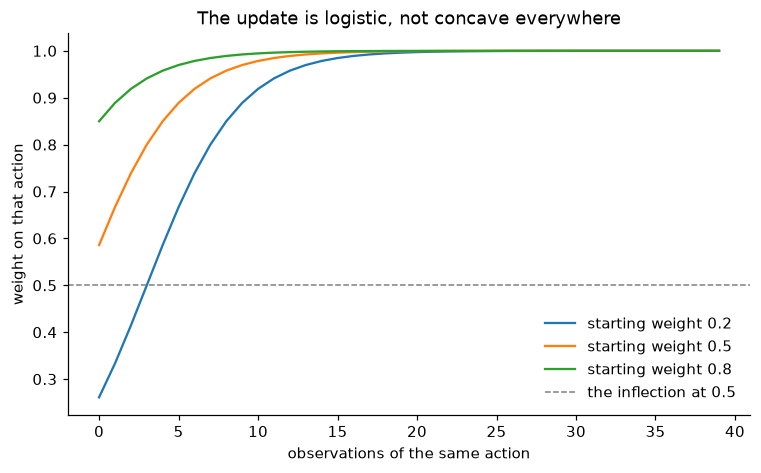

In [3]:
def trajectory(start, eta, rounds=40):
    """The weight path with no sampling noise, to show the shape by itself."""
    w, out = start, []
    for _ in range(rounds):
        w = w * (1 + eta) / (w * (1 + eta) + (1 - w))
        out.append(w)
    return out

fig, ax = plt.subplots()
for start in (0.2, 0.5, 0.8):
    ax.plot(trajectory(start, 0.4142), marker="", label=f"starting weight {start}")
ax.axhline(0.5, ls="--", c="grey", lw=1, label="the inflection at 0.5")
ax.set_xlabel("observations of the same action")
ax.set_ylabel("weight on that action")
ax.set_title("The update is logistic, not concave everywhere")
ax.legend(frameon=False)
fig.savefig("results/update_shape.png", dpi=110, bbox_inches="tight")
plt.show()

## The rule in closed form

The renormalisation makes the update look stateful, and it is not. Divide the
two weights: renormalising scales both by the same total, so it cancels in the
ratio. In terms of the odds `r = w_C / w_D`, observing a cooperation is exactly

```
r  <-  r * (1 + eta)
```

and observing a defection divides by the same factor. Taking logs, the log-odds
move by a constant step per observation, so after `n_C` cooperations and `n_D`
defections seen in any order:

```
w_i  proportional to  w_i(0) * (1 + eta) ** n_i
```

Three consequences, and none of them is visible from the recursion:

1. **The agent's entire state is a pair of counts.** The order it saw them in
   cannot affect what it does next. Whatever this agent is, it is not
   Tit-for-Tat, which is a function of the last round alone.
2. **The trajectory is logistic by construction**, not by observation. The
   figure above draws a curve that the algebra already fixes.
3. **`eta = sqrt(2) - 1` finally means something.** It makes `1 + eta` equal
   `sqrt(2)`, so the odds double every two net observations. That is the only
   reading found under which the constant is a choice rather than an arbitrary
   number, and it is still not the empirical grounding the report claims.

Naming it: weights exponential in a count, normalised, is a Boltzmann
distribution over observation counts at inverse temperature `log(1 + eta)`. That
is the multiplicative-weights family of Cesa-Bianchi, Gentile and Lugosi (2017),
which is reference 4 of `../original/Litterature/README.md` and is never cited
in the report that needed it.


In [4]:
def closed_form_weights(observations, eta=SQRT2_MINUS_1, start=0.8):
    """The weights predicted by the algebra, from counts alone."""
    counts = {"Cooperate": observations.count("Cooperate"),
              "Defect": observations.count("Defect")}
    unnormalised = {"Cooperate": start * (1 + eta) ** counts["Cooperate"],
                    "Defect": (1 - start) * (1 + eta) ** counts["Defect"]}
    total = sum(unnormalised.values())
    return {action: value / total for action, value in unnormalised.items()}


# A sequence with no pattern in it, so a rule that depended on order would fail.
rng = random.Random(SEED)
observations = [rng.choice(["Cooperate", "Defect"]) for _ in range(200)]

recursive = HebbianMirrorNeuronAgent()
for action in observations:
    recursive.observe_and_learn(action)
predicted = closed_form_weights(observations)

largest_gap = max(abs(recursive.weights[a] - predicted[a])
                  for a in ("Cooperate", "Defect"))
assert largest_gap < 1e-12, largest_gap
print(f"200 observations, closed form matches the recursion to {largest_gap:.2e}")

# And the order really is irrelevant: shuffling the same observations lands on
# the same weights, which is the property that rules Tit-for-Tat out.
shuffled = observations[:]
rng.shuffle(shuffled)
reshuffled_agent = HebbianMirrorNeuronAgent()
for action in shuffled:
    reshuffled_agent.observe_and_learn(action)
order_gap = max(abs(recursive.weights[a] - reshuffled_agent.weights[a])
                for a in ("Cooperate", "Defect"))
assert order_gap < 1e-12, order_gap
print(f"same observations in another order, same weights to {order_gap:.2e}")


200 observations, closed form matches the recursion to 1.11e-16
same observations in another order, same weights to 1.11e-16


## Sweeping the learning rate

The three figures the original computed labels for and never rendered.

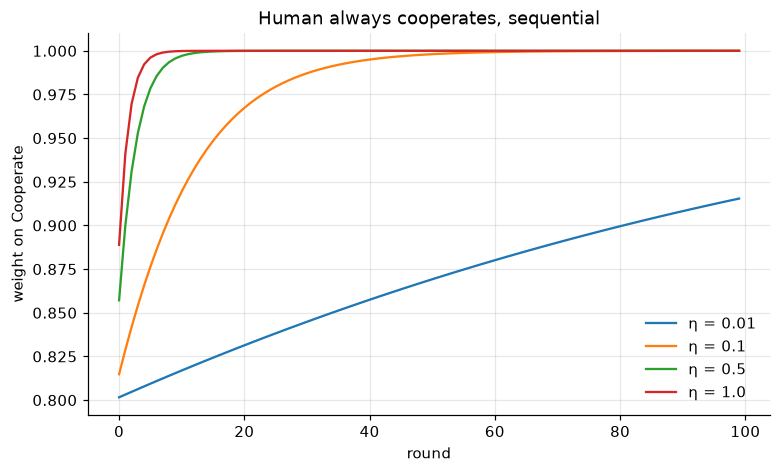

In [5]:
SWEEP = [0.01, 0.1, 0.5, 1.0]

def sweep(human_policy, sequential, title, filename):
    random.seed(SEED); np.random.seed(SEED)
    fig, ax = plt.subplots()
    for eta in SWEEP:
        agent = HebbianMirrorNeuronAgent(learning_rate=eta)
        ax.plot(simulate(agent, human_policy, sequential=sequential), label=f"η = {eta}")
    ax.set_xlabel("round")
    ax.set_ylabel("weight on Cooperate")
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.grid(alpha=0.3)
    fig.savefig(filename, dpi=110, bbox_inches="tight")
    plt.show()

sweep(always_cooperate, True,  "Human always cooperates, sequential", "results/sweep_cooperate_sequential.png")

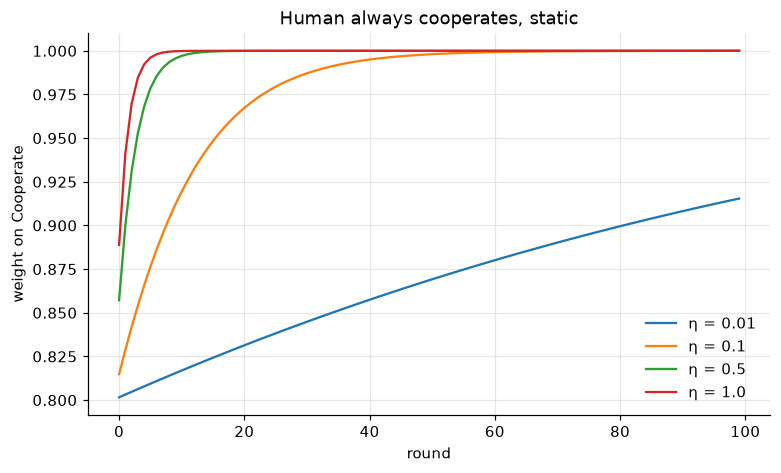

In [6]:
sweep(always_cooperate, False, "Human always cooperates, static", "results/sweep_cooperate_static.png")

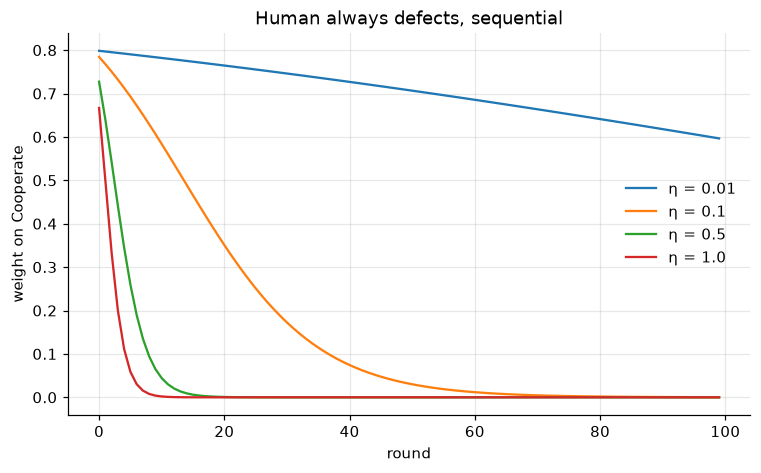

In [7]:
sweep(always_defect, True, "Human always defects, sequential", "results/sweep_defect_sequential.png")

Higher η converges faster and to the same place. The learning rate sets the
speed, not the destination, which is what the write-up says and is now visible
rather than asserted.

## Against the three fixed opponents

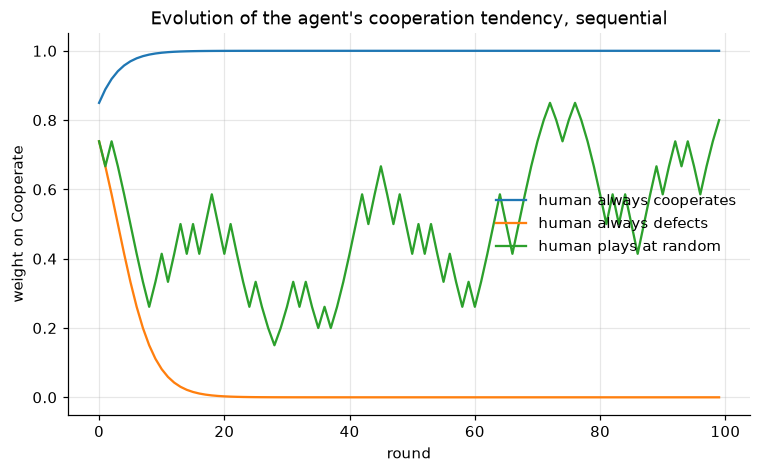

In [8]:
def against_all(sequential, title, filename):
    random.seed(SEED); np.random.seed(SEED)
    fig, ax = plt.subplots()
    for policy, label in ((always_cooperate, "human always cooperates"),
                          (always_defect, "human always defects"),
                          (random_human, "human plays at random")):
        ax.plot(simulate(HebbianMirrorNeuronAgent(), policy, sequential=sequential),
                label=label)
    ax.set_xlabel("round")
    ax.set_ylabel("weight on Cooperate")
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.grid(alpha=0.3)
    fig.savefig(filename, dpi=110, bbox_inches="tight")
    plt.show()

against_all(True, "Evolution of the agent's cooperation tendency, sequential",
            "results/opponents_sequential.png")

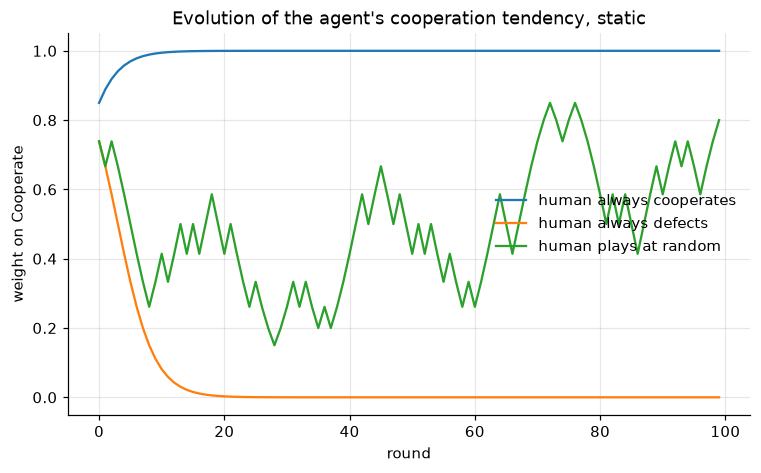

In [9]:
against_all(False, "Evolution of the agent's cooperation tendency, static",
            "results/opponents_static.png")

## A scripted exchange

The original ended with `while(True): input(...)`, which hangs any run-all. Same
demonstration, fixed input, so it terminates.

In [10]:
random.seed(SEED); np.random.seed(SEED)
agent = HebbianMirrorNeuronAgent()
for human_action in ["Cooperate", "Cooperate", "Defect", "Cooperate", "Defect", "Defect"]:
    agent_action = play_static_game(agent, human_action)
    print(f"human {human_action:<10} agent {agent_action:<10} "
          f"weight on Cooperate {agent.weights['Cooperate']:.3f}")

human Cooperate  agent Cooperate  weight on Cooperate 0.850
human Cooperate  agent Cooperate  weight on Cooperate 0.889
human Defect     agent Cooperate  weight on Cooperate 0.850
human Cooperate  agent Cooperate  weight on Cooperate 0.889
human Defect     agent Cooperate  weight on Cooperate 0.850
human Defect     agent Cooperate  weight on Cooperate 0.800


## What the write-up claims that this does not show

Recorded because the PDF sits next to this and a reader will read both.

- It says the agents *"se rapproche du comportement humain"*. There is **no human
  data anywhere in the simulation**. The agent plays three hardcoded fixed
  policies, one of which is a coin flip. Resembling a human is not tested.
- It says the parameters are *"basées sur des données empiriques"* from Ng
  (2023). They are `learning_rate = 2**0.5 - 1` and `cooperation_rate = 0.8`,
  neither of which is traceable to that paper or to any measurement.
- It describes the growth as concave. It is logistic, as the second figure
  shows. The claim holds for the default starting weight and not in general.

None of this touches the idea, which is a reasonable one: imitation as a Hebbian
weight update is a plausible mechanism for Tit-for-Tat appearing without anyone
programming it.